In [65]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import Aer
from qiskit.providers import JobV1 as Job
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit, transpile
import numpy as np

### Deutsch

In [60]:
# define an oracle and a circuit

def twobit_function(case: int):
    """
    Generate a valid two-bit function as a `QuantumCircuit`.
    """

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

def d_circuit(oracle: QuantumCircuit):
    """
    Generate the Deutsch-Jozsa circuit for a given oracle.
    """
    qc_deutsch = QuantumCircuit(2, 1)
    qc_deutsch.x(1)
    qc_deutsch.h([0, 1])
    qc_deutsch.barrier()
    qc_deutsch.compose(oracle, inplace=True)
    qc_deutsch.barrier()
    qc_deutsch.h(0)
    qc_deutsch.measure(0, 0)
    return qc_deutsch

In [63]:
# transpile and run the circuit on a simulator backend

service = QiskitRuntimeService()
backend = service.least_busy()
sampler = Sampler(mode=backend)
print(type(backend))
print(f"Least busy backend: {backend.name}")
print(f"Has {backend.status().pending_jobs} pending jobs.")

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# when using simulator
# backend = Aer.get_backend("qasm_simulator")

qcs = []
job_ids = []
counts_list = []

for case in [1, 2, 3, 4]:
    qc = d_circuit(twobit_function(case))
    compiled_qc = transpile((qc), backend=backend, optimization_level=3)


    job = sampler.run([compiled_qc], shots=1)
    job_id = job.job_id()
    job_ids.append(job_id)


# when using simulator
    # job = backend.run(compiled_qc, shots=1024)
    # counts = job.result().get_counts()
    # counts_list.append(counts)

    qcs.append(qc)

qiskit_runtime_service.__init__:WARNING:2025-11-16 12:10:50,221: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: eloza. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-16 12:10:50,738: Using instance: eloza, plan: open


<class 'qiskit_ibm_runtime.ibm_backend.IBMBackend'>
Least busy backend: ibm_marrakesh
Has 0 pending jobs.


In [97]:
# extract and print the results

for job_id, qc in zip(job_ids, qcs):
# for counts, qc in zip(counts_list, qcs):
    job = service.job(job_id)
    res = job.result()
    counts = res[0].data.c.get_counts()

    print(f"\nCircuit:\n{qc.draw('text')}")
    # qc.draw("mpl", scale=0.7)
    print(f"Counts: {counts}:\t ", end="")
    if "1" in counts:
        print("balanced")
    else:
        print("constant")
    print("=" * 40)



Circuit:
     ┌───┐      ░  ░ ┌───┐┌─┐
q_0: ┤ H ├──────░──░─┤ H ├┤M├
     ├───┤┌───┐ ░  ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░──░───────╫─
     └───┘└───┘ ░  ░       ║ 
c: 1/══════════════════════╩═
                           0 
Counts: {'0': 1}:	 constant

Circuit:
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■───░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 
Counts: {'1': 1}:	 balanced

Circuit:
     ┌───┐      ░            ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■────────░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌───┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║ 
c: 1/════════════════════════════════╩═
                                     0 
Counts: {'1': 1}:	 balanced

Circuit:
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───────░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌───┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
 

### Deutsch-Jozsa

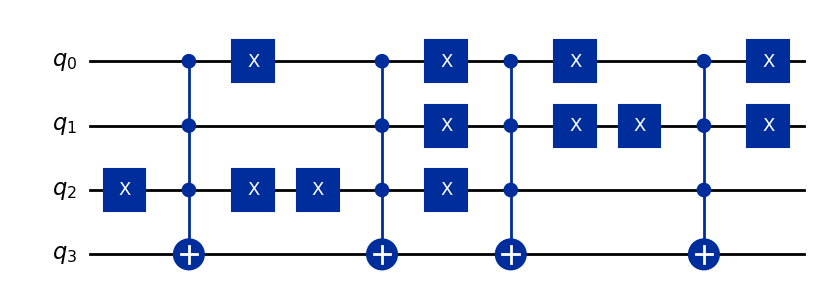

In [94]:
def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """
 
    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance.
        return qc_dj
 
    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:
 
    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
 
    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj
 
    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the 
        # functions are created. They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")
 
    # qc_dj.barrier()
 
    return qc_dj
 
n = 3  # number of input qubits
 
oracle = dj_function(n)
 
oracle.draw("mpl", )

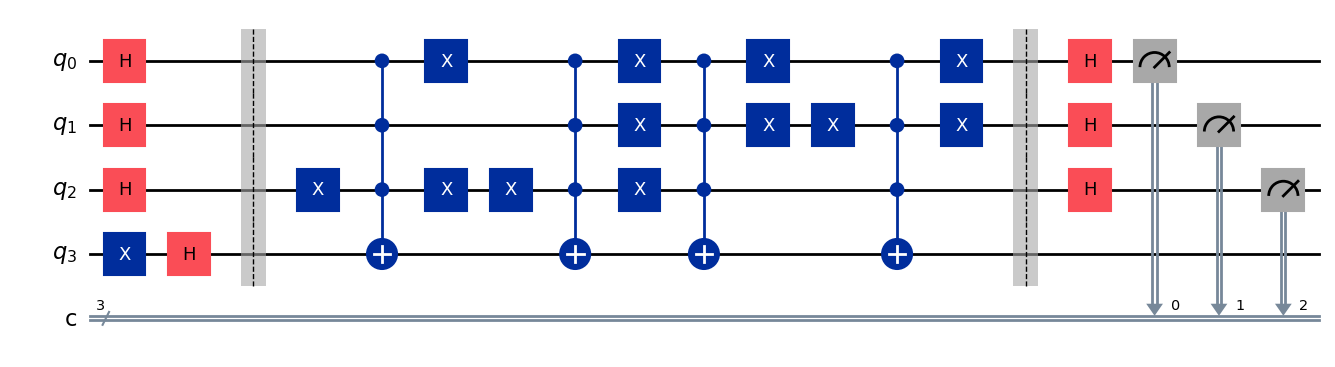

In [95]:
# create a full Deutsch-Jozsa circuit
qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))
 
qc_dj.decompose().decompose()

qc_dj.draw("mpl")

In [96]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

job = sampler.run([qc_isa], shots=1)
job_id = job.job_id()

In [98]:
# Results
# job = service.job(job_id)
job = service.job("d4crhai489vs73a4n040")
res = job.result()
counts = res[0].data.c.get_counts()

print(counts)
if ("0" * n in counts):
    print("constant")
else:
    print("balanced")

{'110': 1}
balanced
